# Exploratory Data Analysis: Aave v3 On-Chain Snapshots

This notebook inspects the **cross-sectional** collateral and debt positions extracted from Aave v3 (Ethereum) at two actuarial valuation dates. Each payload is a blind archive `eth_call` snapshot of `AaveProtocolDataProvider.getUserReserveData`.

- **Baseline scenario:** block `19,433,100` (window ending 15 March 2024) — `data/01_raw/baseline_mar2024/alchemy_snapshot.json`
- **Stress scenario:** block `20,457,180` (window ending 5 August 2024) — `data/01_raw/stress_aug2024/alchemy_snapshot.json`

Balances are stored as **uint256 wei strings** to preserve integer precision. Extraction omitted empty (zero collateral and zero debt) wallet-asset pairs, so the flattened wallet-level tables are sparse by construction.

## 1. Setup and imports

In [2]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 2. Data loading

JSON paths are resolved relative to this notebook (`notebooks/`). The `positions` array is long-format (one wallet-asset pair per record). It is pivoted so that **each row is a wallet** and each column is an asset-specific collateral or debt balance, still in wei strings.

Collateral is `current_a_token_balance`. Debt is `total_debt` (`current_stable_debt + current_variable_debt`). Missing wallet-asset cells are `NaN` because zero positions were dropped at extraction.

In [3]:
RAW_DATA_DIR = Path("../data/01_raw")
BASELINE_SNAPSHOT_PATH = RAW_DATA_DIR / "baseline_mar2024" / "alchemy_snapshot.json"
STRESS_SNAPSHOT_PATH = RAW_DATA_DIR / "stress_aug2024" / "alchemy_snapshot.json"

ASSET_DECIMALS: dict[str, int] = {
    "USDC": 6,
    "USDT": 6,
    "WBTC": 8,
    "WETH": 18,
    "UNI": 18,
    "DAI": 18,
    "FRAX": 18,
    "wstETH": 18,
    "rETH": 18,
    "cbETH": 18,
}
ASSET_SYMBOLS: tuple[str, ...] = tuple(ASSET_DECIMALS.keys())
POSITION_FIELDS: tuple[str, ...] = ("collateral", "debt")
SCENARIO_PALETTE: dict[str, str] = {"Baseline": "#1f4e79", "Stress": "#c44e52"}
TOP_N_ASSETS = 5


def expected_wide_columns(asset_symbols: tuple[str, ...]) -> list[str]:
    """Return the canonical wallet-level column order."""
    return [
        f"{asset}_{field}"
        for asset in asset_symbols
        for field in POSITION_FIELDS
    ]


def flatten_positions_to_wallet_frame(positions: list[dict[str, Any]]) -> pd.DataFrame:
    """Pivot long-format reserve positions into a wallet-level wide table.

    Parameters
    ----------
    positions:
        Records with ``wallet``, ``asset_symbol``, ``current_a_token_balance``,
        and ``total_debt`` (wei strings).

    Returns
    -------
    pd.DataFrame
        Index is ``wallet``. Columns are ``{asset}_collateral`` and
        ``{asset}_debt`` for every target asset. Values remain wei strings.
    """
    column_order = expected_wide_columns(ASSET_SYMBOLS)
    if not positions:
        empty = pd.DataFrame(columns=column_order)
        empty.index.name = "wallet"
        return empty

    long_frame = pd.DataFrame(positions)
    required_fields = {
        "wallet",
        "asset_symbol",
        "current_a_token_balance",
        "total_debt",
    }
    missing_fields = required_fields.difference(long_frame.columns)
    if missing_fields:
        raise ValueError(
            f"Snapshot positions are missing fields: {sorted(missing_fields)}"
        )

    collateral = long_frame.pivot_table(
        index="wallet",
        columns="asset_symbol",
        values="current_a_token_balance",
        aggfunc="first",
    ).add_suffix("_collateral")
    debt = long_frame.pivot_table(
        index="wallet",
        columns="asset_symbol",
        values="total_debt",
        aggfunc="first",
    ).add_suffix("_debt")

    wide = collateral.join(debt, how="outer")
    wide = wide.reindex(columns=column_order)
    wide.index.name = "wallet"
    wide.columns.name = None
    return wide


def load_alchemy_snapshot(json_path: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Load an Alchemy snapshot JSON and flatten it to wallet-level rows."""
    if not json_path.exists():
        raise FileNotFoundError(f"Snapshot file not found: {json_path.resolve()}")

    with json_path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    positions = payload.get("positions")
    if not isinstance(positions, list):
        raise ValueError(f"'positions' array is missing or invalid in {json_path}")

    metadata = {key: value for key, value in payload.items() if key != "positions"}
    wide = flatten_positions_to_wallet_frame(positions)
    return wide, metadata


def print_snapshot_metadata(label: str, metadata: dict[str, Any], json_path: Path) -> None:
    """Print extraction metadata for a loaded snapshot."""
    print(f"{label}")
    print(f"  path            : {json_path.resolve()}")
    print(f"  protocol        : {metadata.get('protocol')}")
    print(f"  network         : {metadata.get('network')}")
    print(f"  block_number    : {metadata.get('block_number')}")
    print(f"  wallet_universe : {metadata.get('wallet_count')}")
    print(f"  rpc_call_count  : {metadata.get('rpc_call_count')}")
    print(f"  position_count  : {metadata.get('position_count')}")
    print(f"  zero_omitted    : {metadata.get('zero_position_count')}")
    print(f"  extracted_at    : {metadata.get('extracted_at_utc')}")


baseline_wei, baseline_meta = load_alchemy_snapshot(BASELINE_SNAPSHOT_PATH)
stress_wei, stress_meta = load_alchemy_snapshot(STRESS_SNAPSHOT_PATH)

print_snapshot_metadata("Baseline (Mar 2024)", baseline_meta, BASELINE_SNAPSHOT_PATH)
print()
print_snapshot_metadata("Stress (Aug 2024)", stress_meta, STRESS_SNAPSHOT_PATH)
print()
print("Baseline wallet-level head (wei strings):")
display(baseline_wei.head())

Baseline (Mar 2024)
  path            : C:\Users\facun\Repos\Tesina\data\01_raw\baseline_mar2024\alchemy_snapshot.json
  protocol        : aave-v3
  network         : ethereum
  block_number    : 19433100
  wallet_universe : 29757
  rpc_call_count  : 297570
  position_count  : 28481
  zero_omitted    : 269089
  extracted_at    : 2026-09-19T04:13:23.971265+00:00

Stress (Aug 2024)
  path            : C:\Users\facun\Repos\Tesina\data\01_raw\stress_aug2024\alchemy_snapshot.json
  protocol        : aave-v3
  network         : ethereum
  block_number    : 20457180
  wallet_universe : 46536
  rpc_call_count  : 465360
  position_count  : 42410
  zero_omitted    : 422950
  extracted_at    : 2026-09-19T17:09:43.348910+00:00

Baseline wallet-level head (wei strings):


,USDC_collateral,USDC_debt,USDT_collateral,USDT_debt,WBTC_collateral,WBTC_debt,WETH_collateral,WETH_debt,UNI_collateral,UNI_debt,DAI_collateral,DAI_debt,FRAX_collateral,FRAX_debt,wstETH_collateral,wstETH_debt,rETH_collateral,rETH_debt,cbETH_collateral,cbETH_debt
wallet,,,,,,,,,,,,,,,,,,,,
0x00000000032962b51589768828ad878876299e14,NaN,NaN,NaN,NaN,NaN,NaN,54337464356638,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x000000005debd78f9271e9f0363beebdc2fc415b,NaN,NaN,NaN,NaN,NaN,NaN,3145275620995837,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x000000093e55f433fb57a32aa5d5fe717b3f7ab1,2835,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x00000015e180b01c40b881e10774bc784bb6f4eb,NaN,NaN,NaN,NaN,NaN,NaN,20167409365224591,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x0000031cd1dcf3c17083686867b86f25c4500000,NaN,NaN,NaN,NaN,NaN,NaN,3567570036831,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Wei conversion

Each ERC-20 uses a different decimal scale. Conversion is **vectorized per column**: `pd.to_numeric` parses the wei strings, then divides by `10 ** decimals`.

| Assets | Decimals | Divisor |
| --- | ---: | ---: |
| USDC, USDT | 6 | `1e6` |
| WBTC | 8 | `1e8` |
| WETH, UNI, DAI, FRAX, wstETH, rETH, cbETH | 18 | `1e18` |

IEEE-754 `float64` cannot represent every uint256 integer exactly. The residual error is negligible for exploratory aggregates, but the raw wei strings remain the source of truth for any later exact arithmetic.

In [4]:
def wei_strings_to_tokens(wei_values: pd.Series, decimals: int) -> pd.Series:
    """Convert a column of uint256 wei strings to native-token float64 amounts.

    Parameters
    ----------
    wei_values:
        Series of integer strings (or numeric values) denominated in wei.
    decimals:
        Token decimal places from the underlying ERC-20 contract.

    Returns
    -------
    pd.Series
        Token balances as ``float64``. Invalid entries become ``NaN``.
    """
    if decimals < 0:
        raise ValueError(f"decimals must be non-negative, got {decimals}.")
    divisor = 10 ** decimals
    return pd.to_numeric(wei_values, errors="coerce") / divisor


def convert_wide_wei_to_tokens(
    wide_wei: pd.DataFrame,
    decimals_map: dict[str, int],
) -> pd.DataFrame:
    """Apply asset-specific wei scaling to every collateral and debt column."""
    converted = pd.DataFrame(index=wide_wei.index)
    for column in wide_wei.columns:
        asset_symbol, _, _field = column.rpartition("_")
        if asset_symbol not in decimals_map:
            raise KeyError(
                f"No decimal mapping for asset '{asset_symbol}' in column '{column}'."
            )
        converted[column] = wei_strings_to_tokens(
            wide_wei[column],
            decimals_map[asset_symbol],
        )
    converted.index.name = wide_wei.index.name
    return converted


baseline_tokens = convert_wide_wei_to_tokens(baseline_wei, ASSET_DECIMALS)
stress_tokens = convert_wide_wei_to_tokens(stress_wei, ASSET_DECIMALS)

print("Baseline dtypes after wei conversion:")
print(baseline_tokens.dtypes.to_string())
print()
print("Baseline wallet-level head (native tokens):")
display(baseline_tokens.head())

Baseline dtypes after wei conversion:
USDC_collateral      float64
USDC_debt            float64
USDT_collateral      float64
USDT_debt            float64
WBTC_collateral      float64
WBTC_debt            float64
WETH_collateral      float64
WETH_debt            float64
UNI_collateral       float64
UNI_debt             float64
DAI_collateral       float64
DAI_debt             float64
FRAX_collateral      float64
FRAX_debt            float64
wstETH_collateral    float64
wstETH_debt          float64
rETH_collateral      float64
rETH_debt            float64
cbETH_collateral     float64
cbETH_debt           float64

Baseline wallet-level head (native tokens):


,USDC_collateral,USDC_debt,USDT_collateral,USDT_debt,WBTC_collateral,WBTC_debt,WETH_collateral,WETH_debt,UNI_collateral,UNI_debt,DAI_collateral,DAI_debt,FRAX_collateral,FRAX_debt,wstETH_collateral,wstETH_debt,rETH_collateral,rETH_debt,cbETH_collateral,cbETH_debt
wallet,,,,,,,,,,,,,,,,,,,,
0x00000000032962b51589768828ad878876299e14,NaN,NaN,NaN,NaN,NaN,NaN,0.000054,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x000000005debd78f9271e9f0363beebdc2fc415b,NaN,NaN,NaN,NaN,NaN,NaN,0.003145,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x000000093e55f433fb57a32aa5d5fe717b3f7ab1,0.002835,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x00000015e180b01c40b881e10774bc784bb6f4eb,NaN,NaN,NaN,NaN,NaN,NaN,0.020167,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0x0000031cd1dcf3c17083686867b86f25c4500000,NaN,NaN,NaN,NaN,NaN,NaN,0.000004,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Basic data quality

For each scenario, report unique wallets, column count, and nulls introduced by the pivot. Structural `NaN` values are expected: a wallet appears in the wide table if it has **at least one** non-empty reserve, but not necessarily a position in every asset. After the quality report, missing cells are filled with `0.0` so aggregates treat omitted positions as true zeros.

In [5]:
def report_data_quality(
    label: str,
    wide_wei: pd.DataFrame,
    metadata: dict[str, Any],
) -> None:
    """Print uniqueness, shape, and flattening-induced null diagnostics."""
    n_wallets = wide_wei.index.nunique()
    n_rows, n_cols = wide_wei.shape
    duplicate_wallets = int(wide_wei.index.duplicated().sum())
    null_counts = wide_wei.isna().sum()
    total_nulls = int(null_counts.sum())
    null_share = total_nulls / wide_wei.size if wide_wei.size else 0.0

    print(f"{label}")
    print(f"  unique wallets          : {n_wallets:,}")
    print(f"  extraction universe     : {metadata.get('wallet_count'):,}")
    print(f"  rows x columns          : {n_rows:,} x {n_cols:,}")
    print(f"  duplicate wallet index  : {duplicate_wallets:,}")
    print(f"  flattening null cells   : {total_nulls:,} ({null_share:.1%} of cells)")
    print(f"  columns with any null   : {int((null_counts > 0).sum()):,}")
    if n_wallets != n_rows:
        print("  WARNING: row count does not match unique wallets.")
    if duplicate_wallets:
        print("  WARNING: duplicate wallet identifiers in the index.")
    print("  nulls by column:")
    print(null_counts.to_string())
    print()


report_data_quality("Baseline (Mar 2024)", baseline_wei, baseline_meta)
report_data_quality("Stress (Aug 2024)", stress_wei, stress_meta)

baseline_tokens = baseline_tokens.fillna(0.0)
stress_tokens = stress_tokens.fillna(0.0)

print("Null cells after fillna(0) | baseline:", int(baseline_tokens.isna().sum().sum()))
print("Null cells after fillna(0) | stress  :", int(stress_tokens.isna().sum().sum()))

Baseline (Mar 2024)
  unique wallets          : 17,307
  extraction universe     : 29,757
  rows x columns          : 17,307 x 20
  duplicate wallet index  : 0
  flattening null cells   : 289,178 (83.5% of cells)
  columns with any null   : 20
  nulls by column:
USDC_collateral      11202
USDC_debt            11202
USDT_collateral      12952
USDT_debt            12952
WBTC_collateral      14745
WBTC_debt            14745
WETH_collateral       6355
WETH_debt             6355
UNI_collateral       17082
UNI_debt             17082
DAI_collateral       15178
DAI_debt             15178
FRAX_collateral      17225
FRAX_debt            17225
wstETH_collateral    15461
wstETH_debt          15461
rETH_collateral      17307
rETH_debt            17307
cbETH_collateral     17082
cbETH_debt           17082

Stress (Aug 2024)
  unique wallets          : 26,093
  extraction universe     : 46,536
  rows x columns          : 26,093 x 20
  duplicate wallet index  : 0
  flattening null cells   : 437,040 (8

## 5. Aggregated analytics

Token-denominated **TVL** is the sum of aToken collateral across wallets, by asset. **Total debt** is the sum of stable plus variable debt, by asset. These figures are **not USD-normalized**: USDC units are not comparable with WETH or WBTC units. Wallet counts measure utilization independently of token scale.

In [6]:
def build_asset_aggregates(token_df: pd.DataFrame, scenario: str) -> pd.DataFrame:
    """Sum native-token collateral TVL and total debt per asset."""
    records: list[dict[str, Any]] = []
    for asset in ASSET_SYMBOLS:
        collateral = token_df[f"{asset}_collateral"]
        debt = token_df[f"{asset}_debt"]
        records.append(
            {
                "scenario": scenario,
                "asset": asset,
                "decimals": ASSET_DECIMALS[asset],
                "collateral_tvl": float(collateral.sum()),
                "total_debt": float(debt.sum()),
                "collateral_wallets": int((collateral > 0).sum()),
                "debt_wallets": int((debt > 0).sum()),
            }
        )
    return pd.DataFrame(records)


aggregates = pd.concat(
    [
        build_asset_aggregates(baseline_tokens, "Baseline"),
        build_asset_aggregates(stress_tokens, "Stress"),
    ],
    ignore_index=True,
)

print("Collateral TVL and total debt by asset (native token units)")
display(aggregates)

pivot_collateral = aggregates.pivot(
    index="asset", columns="scenario", values="collateral_tvl"
).reindex(ASSET_SYMBOLS)[["Baseline", "Stress"]]
pivot_debt = aggregates.pivot(
    index="asset", columns="scenario", values="total_debt"
).reindex(ASSET_SYMBOLS)[["Baseline", "Stress"]]

print("Collateral TVL (native tokens)")
display(pivot_collateral)
print("Total debt (native tokens)")
display(pivot_debt)

Collateral TVL and total debt by asset (native token units)


,scenario,asset,decimals,collateral_tvl,total_debt,collateral_wallets,debt_wallets
0,Baseline,USDC,6,"1,051,429,049.728596","965,155,500.548769",2900,3404
1,Baseline,USDT,6,"773,793,358.083037","715,036,060.288205",1794,2654
2,Baseline,WBTC,8,"24,794.476005","2,673.417430",2378,262
3,Baseline,WETH,18,"661,045.568618","517,072.751403",10277,1037
4,Baseline,UNI,18,"1,566,468.275798","30,070.799996",158,67
5,Baseline,DAI,18,"152,009,234.420263","139,294,425.108343",1080,1111
6,Baseline,FRAX,18,"644,491.780658","617,965.157068",18,64
7,Baseline,wstETH,18,"947,676.441692","4,078.494207",1676,230
8,Baseline,rETH,18,0.000000,0.000000,0,0
9,Baseline,cbETH,18,"8,388.816918",302.107513,175,63


Collateral TVL (native tokens)


scenario,Baseline,Stress
asset,,
USDC,"1,051,429,049.728596","1,525,510,616.036997"
USDT,"773,793,358.083037","1,659,210,216.383682"
WBTC,"24,794.476005","35,699.978092"
WETH,"661,045.568618","1,020,573.286637"
UNI,"1,566,468.275798","1,886,014.745602"
DAI,"152,009,234.420263","131,252,777.575714"
FRAX,"644,491.780658","826,209.187096"
wstETH,"947,676.441692","1,036,020.318420"
rETH,0.000000,0.000000


Total debt (native tokens)


scenario,Baseline,Stress
asset,,
USDC,"965,155,500.548769","1,351,186,140.138499"
USDT,"715,036,060.288205","1,346,690,231.129894"
WBTC,"2,673.417430","4,608.899814"
WETH,"517,072.751403","893,263.713473"
UNI,"30,070.799996","25,885.446600"
DAI,"139,294,425.108343","117,422,778.573680"
FRAX,"617,965.157068","717,188.058084"
wstETH,"4,078.494207","20,992.935408"
rETH,0.000000,0.000000


## 6. Comparative visualization

The top five collateral assets and the top five borrowed assets are ranked by **wallet count summed across both scenarios** (utilization, not USD value). Grouped bars compare Baseline versus Stress.

- **Top row:** number of wallets with a strictly positive balance — the utilization ranking itself.
- **Bottom row:** summed native-token amounts for the same assets. The y-axis is logarithmic because ERC-20 units are not comparable across assets; the informative contrast is Baseline versus Stress **within** each asset.

Top 5 collateral assets by wallet count: ['WETH', 'USDC', 'WBTC', 'USDT', 'wstETH']
Top 5 borrowed assets by wallet count : ['USDC', 'USDT', 'WETH', 'DAI', 'WBTC']


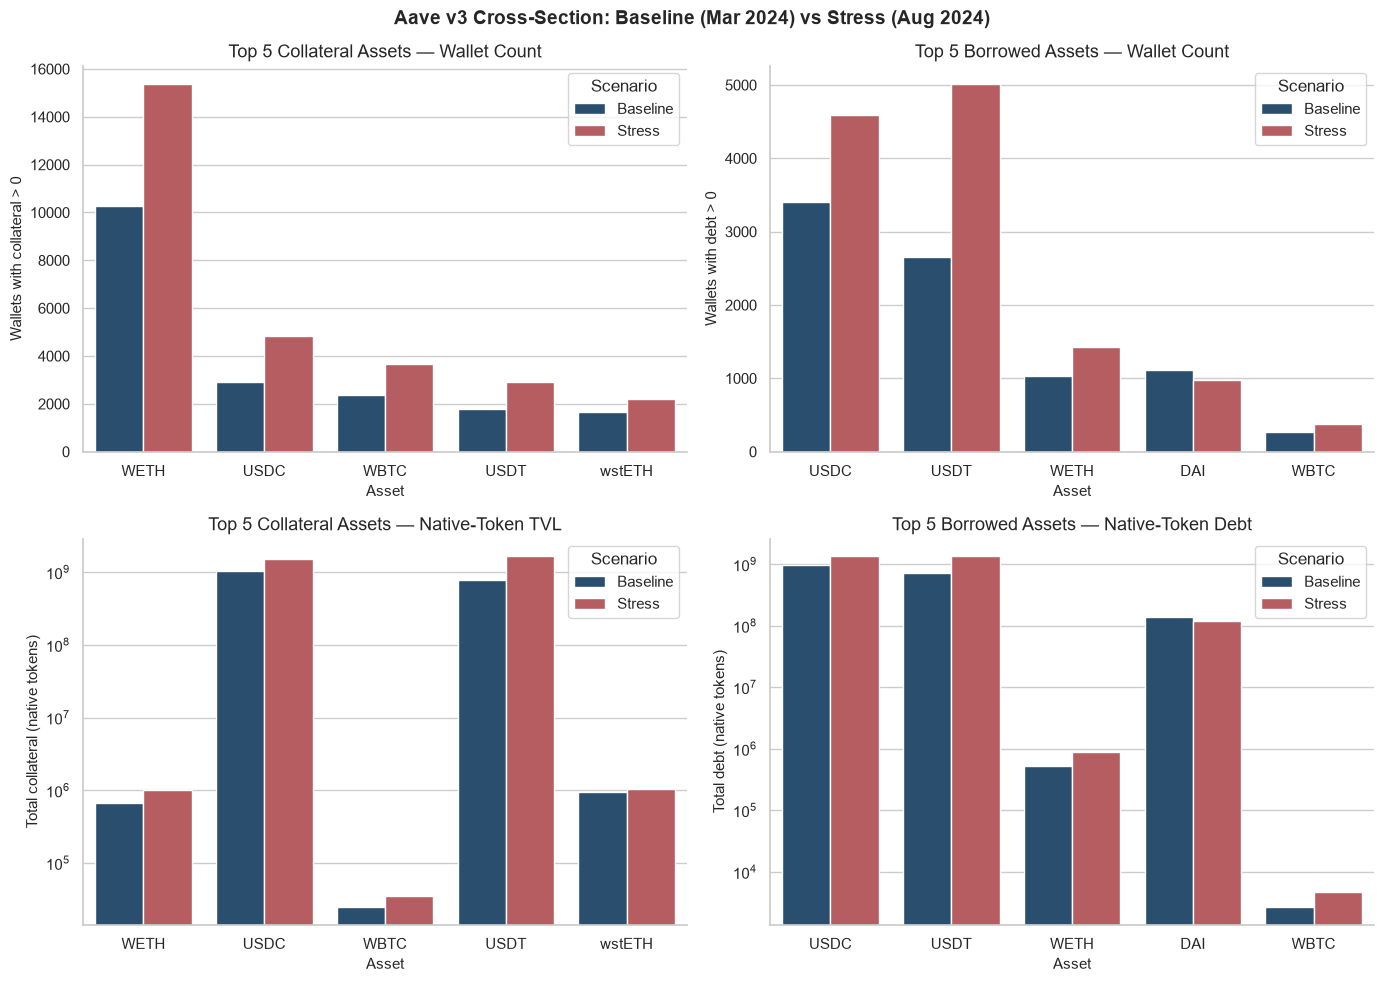

In [7]:
def rank_top_assets(
    frame: pd.DataFrame,
    wallet_col: str,
    n: int = TOP_N_ASSETS,
) -> list[str]:
    """Return the n assets with the highest combined-scenario wallet counts."""
    ranked = (
        frame.groupby("asset", as_index=True)[wallet_col]
        .sum()
        .sort_values(ascending=False)
    )
    return ranked.head(n).index.tolist()


def subset_ranked(frame: pd.DataFrame, assets: list[str]) -> pd.DataFrame:
    """Filter aggregates and freeze the bar order to the utilization rank."""
    subset = frame[frame["asset"].isin(assets)].copy()
    subset["asset"] = pd.Categorical(subset["asset"], categories=assets, ordered=True)
    return subset.sort_values(["asset", "scenario"])


top_collateral_assets = rank_top_assets(aggregates, "collateral_wallets")
top_debt_assets = rank_top_assets(aggregates, "debt_wallets")

collateral_plot = subset_ranked(aggregates, top_collateral_assets)
debt_plot = subset_ranked(aggregates, top_debt_assets)

print("Top 5 collateral assets by wallet count:", top_collateral_assets)
print("Top 5 borrowed assets by wallet count :", top_debt_assets)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(
    data=collateral_plot,
    x="asset",
    y="collateral_wallets",
    hue="scenario",
    palette=SCENARIO_PALETTE,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Top 5 Collateral Assets — Wallet Count")
axes[0, 0].set_xlabel("Asset")
axes[0, 0].set_ylabel("Wallets with collateral > 0")
axes[0, 0].legend(title="Scenario")

sns.barplot(
    data=debt_plot,
    x="asset",
    y="debt_wallets",
    hue="scenario",
    palette=SCENARIO_PALETTE,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Top 5 Borrowed Assets — Wallet Count")
axes[0, 1].set_xlabel("Asset")
axes[0, 1].set_ylabel("Wallets with debt > 0")
axes[0, 1].legend(title="Scenario")

sns.barplot(
    data=collateral_plot,
    x="asset",
    y="collateral_tvl",
    hue="scenario",
    palette=SCENARIO_PALETTE,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Top 5 Collateral Assets — Native-Token TVL")
axes[1, 0].set_xlabel("Asset")
axes[1, 0].set_ylabel("Total collateral (native tokens)")
axes[1, 0].legend(title="Scenario")
if (collateral_plot["collateral_tvl"] > 0).all():
    axes[1, 0].set_yscale("log")

sns.barplot(
    data=debt_plot,
    x="asset",
    y="total_debt",
    hue="scenario",
    palette=SCENARIO_PALETTE,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Top 5 Borrowed Assets — Native-Token Debt")
axes[1, 1].set_xlabel("Asset")
axes[1, 1].set_ylabel("Total debt (native tokens)")
axes[1, 1].legend(title="Scenario")
if (debt_plot["total_debt"] > 0).all():
    axes[1, 1].set_yscale("log")

fig.suptitle(
    "Aave v3 Cross-Section: Baseline (Mar 2024) vs Stress (Aug 2024)",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()
plt.show()